#**Introducción**

###El objetivo de este proyecto es el poder comprender la evasión de clientes en la empresa Telecom X. Por tanto para eso es necesario este analisis, dado que la evasion pasa cuando un cliente decide cancelar el servicio contratado con la empresa

###Lo que a la larga representa una pardida directa de ingresos y puede afectar la estabilidad del negocio. Asi que el poder identificar los factores que influyen es vital para poder diseñar estrategias que permitan mejorar la retencio de clientes.


#📌 Extracción

###1 - Extracción de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
datos = pd.read_json('/content/drive/MyDrive/Colab Notebooks/TelecomX_Data.json')

### 2 - Conoce el conjunto de datos

In [4]:
datos.shape

(7267, 6)

In [5]:
datos.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
datos.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [8]:
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

##Limpieza y Tratamiento de Datos

###En esta parte del proyecto basicamente, se paso de tener datos "sucios" y desordenados a tener una tabla limpia y lista para analizar. En este caso al usar value_counts(), se descubrió que había 224 celdas con un espacio vacío (' ').

###Por tanto esos espacion fueron convertidos en valores nulos reales (pd.NA) y luego se borraron esas filas con dropna(). Asegurando asi de trabajar solo con informacion completa.

* Ademas que se aplanaron las columnas, pues eran datos que estaban guardados como en una lista dentro de una sola celda. Por eso se uso pd.json_normalize

###1 - Comprobación de incoherencias en los datos

In [9]:
#OJO aqui con las '' vacias
pd.unique(datos['Churn'])

array(['No', 'Yes', ''], dtype=object)

In [10]:
datos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [11]:
print(datos['Churn'].isnull().sum())

0


In [12]:
datos['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [13]:
print("--- Valores que son nulos ---")
print(datos.isnull().sum())

--- Valores que son nulos ---
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


###2 - Manejo de inconsistencias

* Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

In [14]:
#El problemita que habia con las '' vacias es quitado
datos['Churn'] = datos['Churn'].replace('', pd.NA)
datos = datos.dropna(subset=['Churn'])

In [15]:
import ast

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Verificar que ahora sí son dict
print(type(datos['customer'][0]))

<class 'dict'>


In [18]:
# Aplanar las columnas porque estan ANIDADAS
customer_df = pd.json_normalize(datos['customer'])
phone_df    = pd.json_normalize(datos['phone'])
internet_df = pd.json_normalize(datos['internet'])
account_df  = pd.json_normalize(datos['account'])

In [19]:
df = pd.concat([datos[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df],axis=1)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.isnull().sum()

,0
customerID,213
Churn,213
gender,213
SeniorCitizen,213
Partner,213
Dependents,213
tenure,213
PhoneService,213
MultipleLines,213
InternetService,213


In [22]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0.0,Yes,Yes,9.0,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0.0,No,No,9.0,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0.0,No,No,4.0,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1.0,Yes,No,13.0,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1.0,Yes,No,3.0,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6980,NaN,NaN,Female,1.0,No,No,1.0,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,No,Mailed check,25.05,25.05
7002,NaN,NaN,Female,0.0,No,No,15.0,Yes,No,DSL,...,Yes,Yes,Yes,Yes,Yes,Month-to-month,No,Mailed check,84.45,1287.85
7009,NaN,NaN,Male,0.0,No,No,32.0,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),85.65,2664.3
7016,NaN,NaN,Male,0.0,Yes,No,69.0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),60.80,4263.4


### 3 - Columna de cuentas diarias

* Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

* 📌 Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [23]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [24]:
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [25]:
# Crear columna de cuentas diarias
df['Cuentas_Diarias'] = (df['Charges.Monthly'] / 30).round(2)

In [26]:
print(df[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6             2.19
1             59.9             2.00
2             73.9             2.46
3             98.0             3.27
4             83.9             2.80


In [27]:
df['Cuentas_Diarias'].head()

,Cuentas_Diarias
0,2.19
1,2.00
2,2.46
3,3.27
4,2.80


### 4 - Estandarización y transformación de datos

####La estandarización y transformación de datos es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más consistente, comprensible y adecuada para el análisis.

* Durante esta fase, por ejemplo, puedes convertir valores textuales como "Sí" y "No" en valores binarios (1 y 0), lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

* Además, traducir o renombrar columnas y datos hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos.

* Aunque no es un paso obligatorio, puede mejorar significativamente la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [28]:
#Para convertir en Si y No a binarios
df.replace({'Yes': 1, 'No': 0}, inplace=True)

In [29]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

In [30]:
#Se pide que se renombren algunas columnas
df.rename(columns={'customerID': 'ClienteID','Charges.Monthly': 'CargoMensual','Charges.Total': 'CargoTotal', 'tenure': 'MesesCliente'}, inplace=True)

In [31]:
df.head()

,ClienteID,Churn,gender,SeniorCitizen,Partner,Dependents,MesesCliente,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CargoMensual,CargoTotal,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0.0,1.0,1.0,9.0,1.0,0,DSL,...,0,1,1,0,One year,1.0,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0.0,0.0,0.0,9.0,1.0,1,DSL,...,0,0,0,1,Month-to-month,0.0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0.0,0.0,0.0,4.0,1.0,0,Fiber optic,...,1,0,0,0,Month-to-month,1.0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1.0,1.0,0.0,13.0,1.0,0,Fiber optic,...,1,0,1,1,Month-to-month,1.0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1.0,1.0,0.0,3.0,1.0,0,Fiber optic,...,0,1,1,0,Month-to-month,1.0,Mailed check,83.9,267.40,2.80


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ClienteID         7043 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   float64
 4   Partner           7043 non-null   float64
 5   Dependents        7043 non-null   float64
 6   MesesCliente      7043 non-null   float64
 7   PhoneService      7043 non-null   float64
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

#📊 Carga y análisis

##Analisis Exploratorio de Datos
###Dentro de los hallazgos se identifico cuánta gente se estaba yendo. Siendo un grupo grande de mas de 7,000 clientes, la gran mayoría decide quedarse, pero hay un grupo considerable de casi 1,900 personas que cancelaron el servicio.

###Y esto nos da una señal de alerta para entender qué está pasando con ese porcentaje que abandona la empresa. Al revisar el tipo de contrato, vemos que los clientes que pagan mes a mes son los que más se van, probablemente porque no tienen un compromiso a largo plazo.

* En cambio, quienes firman por uno o dos años suelen ser mucho más fieles y estables. Y tambien influye como pagan los clientes. Se descubrio que las personas que usan el cheque electrónico cancelan mucho más que aquellas que tienen sus pagos automatizados con tarjeta o transferencia.



### 1 - Análisis Descriptivo

* Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

In [33]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,MesesCliente,PhoneService,PaperlessBilling,CargoMensual,CargoTotal,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [34]:
print("Media:")
print(df.mean(numeric_only=True))

Media:
Churn                  0.265370
SeniorCitizen          0.162147
Partner                0.483033
Dependents             0.299588
MesesCliente          32.371149
PhoneService           0.903166
PaperlessBilling       0.592219
CargoMensual          64.761692
CargoTotal          2283.300441
Cuentas_Diarias        2.158675
dtype: float64


In [35]:
#Vemos cuantos clientes se quedan y cuantos se van
df['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [36]:
print("Mediana:")
print(df.median(numeric_only=True))

Mediana:
Churn                  0.000
SeniorCitizen          0.000
Partner                0.000
Dependents             0.000
MesesCliente          29.000
PhoneService           1.000
PaperlessBilling       1.000
CargoMensual          70.350
CargoTotal          1397.475
Cuentas_Diarias        2.340
dtype: float64


In [37]:
#Este es el promedio de gasto mensual OJO
df['CargoMensual'].mean()

np.float64(64.76169246059918)

In [38]:
print("Desviación estandar:")
print(df.std(numeric_only=True))

Desviación estandar:
Churn                  0.441561
SeniorCitizen          0.368612
Partner                0.499748
Dependents             0.458110
MesesCliente          24.559481
PhoneService           0.295752
PaperlessBilling       0.491457
CargoMensual          30.090047
CargoTotal          2266.771362
Cuentas_Diarias        1.003088
dtype: float64


### 2 - Distribución de evasión

* En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

In [39]:
import matplotlib.pyplot as plt

In [40]:
churn_counts = df['Churn'].value_counts()

print("Distribucion de Churn:")
print(churn_counts)

Distribucion de Churn:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


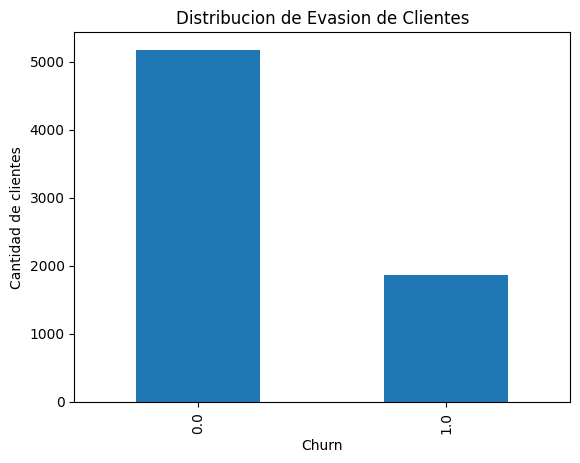

In [41]:
#Si es 0 significa que se queda el cliente
#En cambio si es 1 es que cancela el sevicio

churn_counts.plot(kind='bar')
plt.title("Distribucion de Evasion de Clientes")
plt.ylabel("Cantidad de clientes")

plt.show()

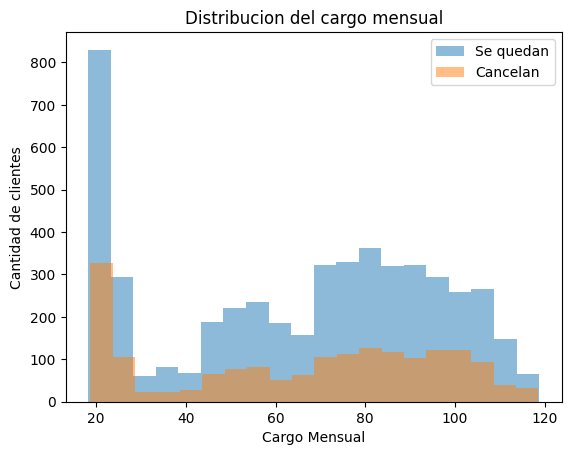

In [42]:
#El cargo mensual vs churn
#Estos son los clientes que se quedaron
df[df['Churn'] == 0]['CargoMensual'].plot(kind='hist', alpha=0.5, bins=20)

#Y aqui los clientes que cancelaron
df[df['Churn'] == 1]['CargoMensual'].plot(kind='hist', alpha=0.5, bins=20)

plt.title("Distribucion del cargo mensual")
plt.xlabel("Cargo Mensual")
plt.ylabel("Cantidad de clientes")

plt.legend(["Se quedan", "Cancelan"])

plt.show()

### 3 - Recuento de evasión por variables categóricas

* Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras. Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

In [43]:
import matplotlib.pyplot as plt

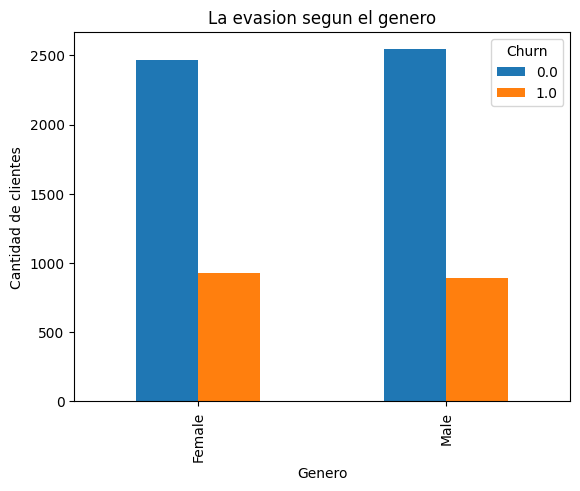

In [44]:
#Aqui es con el genero
#El grafico muestra la cantidad de clientes que permanecieron (0) y los que cancelaron el servicio (1) segun el género.
#0 es masculino y 1 es femenino

pd.crosstab(df['gender'], df['Churn']).plot(kind='bar')
plt.title("La evasion segun el genero")
plt.xlabel("Genero")
plt.ylabel("Cantidad de clientes")

plt.show()

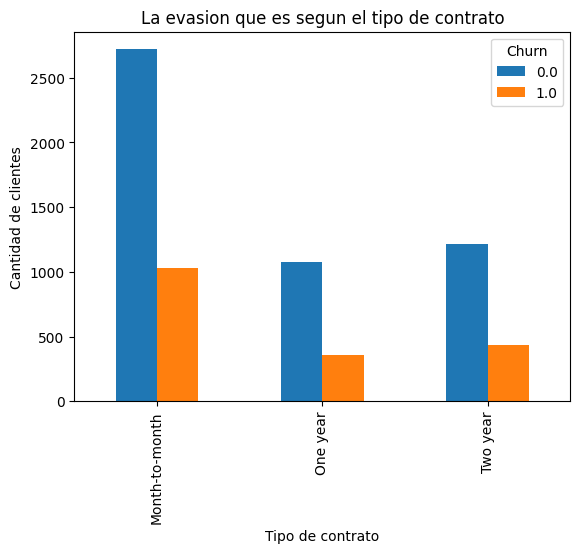

In [45]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')

plt.title("La evasion que es segun el tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

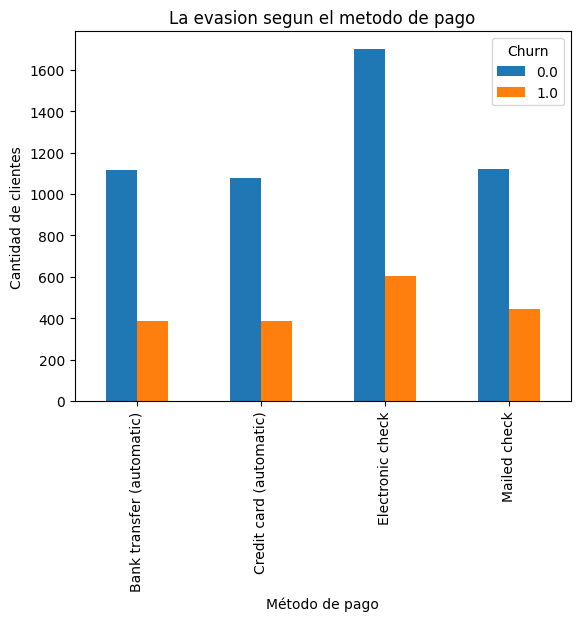

In [46]:
pd.crosstab(df['PaymentMethod'], df['Churn']).plot(kind='bar')
plt.title("La evasion segun el metodo de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.show()

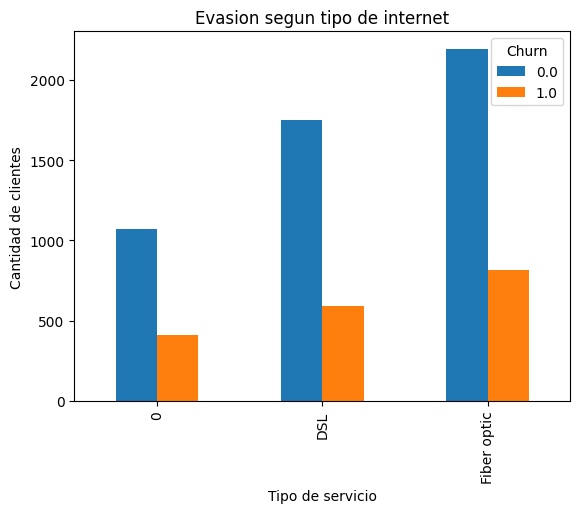

In [47]:
pd.crosstab(df['InternetService'], df['Churn']).plot(kind='bar')

plt.title("Evasion segun tipo de internet")
plt.xlabel("Tipo de servicio")
plt.ylabel("Cantidad de clientes")

plt.show()

### 4 - Conteo de evasión por variables numéricas

* En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

* Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

In [48]:
import plotly.express as px

In [49]:
#Este grafico muestra cómo se distribuye el cargo mensual entre clientes que cancelaron y los que no.
##Si nos fijamos cuanto mas cara es la factura mensual es mas probable es que el cliente cancele el servicio. Los de azul pagan poco, pero son los mas fieles y tienden a quedarse.

fig = px.histogram(df,x="CargoMensual",color="Churn",nbins=30,title="Distribución del cargo mensual según evasión")
fig.show()

In [50]:
#Aqui estan los clientes que gastaron menos o más dinero tienden a cancelar.
fig = px.histogram(df,x="CargoTotal",color="Churn",nbins=30,title="Distribución del total gastado según evasión")
fig.show()

In [51]:
#Con este vemos si los clientes que cancelan tienen menos tiempo con la empresa.
fig = px.box(df,x="Churn",y="MesesCliente",title="Meses como cliente segun evasión")
fig.show()

In [52]:
import plotly.express as px

In [53]:
#Es el tipo de contrato vs churn
pd.crosstab(df['Contract'], df['Churn'])

Churn,0.0,1.0
Contract,,
Month-to-month,2720,1031
One year,1075,354
Two year,1214,436


In [54]:
print(df['MesesCliente'].mean())

32.37114865824223


In [55]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,0.0,1.0
PaymentMethod,,
Bank transfer (automatic),1115,388
Credit card (automatic),1076,385
Electronic check,1700,602
Mailed check,1118,446


In [56]:
list(df.columns)

['ClienteID',
 'Churn',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'MesesCliente',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'CargoMensual',
 'CargoTotal',
 'Cuentas_Diarias']

In [57]:
df.isnull().sum()

,0
ClienteID,213
Churn,213
gender,213
SeniorCitizen,213
Partner,213
Dependents,213
MesesCliente,213
PhoneService,213
MultipleLines,213
InternetService,213


In [58]:
df.shape

(7256, 22)

In [59]:
df = df.dropna(subset=['Churn'])

In [60]:
df.shape

(7043, 22)

In [61]:
df = df.dropna()

In [62]:
df.isnull().sum()

,0
ClienteID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
MesesCliente,0
PhoneService,0
MultipleLines,0
InternetService,0


In [63]:
df.shape

(6819, 22)

#🛠️ Preparación de los Datos

### 1 - Extracción del Archivo Tratado

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [64]:
datos = pd.read_json('/content/drive/MyDrive/Colab Notebooks/TelecomX_Data.json')

In [65]:
df.head()

,ClienteID,Churn,gender,SeniorCitizen,Partner,Dependents,MesesCliente,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CargoMensual,CargoTotal,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0.0,1.0,1.0,9.0,1.0,0,DSL,...,0,1,1,0,One year,1.0,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0.0,0.0,0.0,9.0,1.0,1,DSL,...,0,0,0,1,Month-to-month,0.0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0.0,0.0,0.0,4.0,1.0,0,Fiber optic,...,1,0,0,0,Month-to-month,1.0,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1.0,1.0,0.0,13.0,1.0,0,Fiber optic,...,1,0,1,1,Month-to-month,1.0,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1.0,1.0,0.0,3.0,1.0,0,Fiber optic,...,0,1,1,0,Month-to-month,1.0,Mailed check,83.9,267.40,2.80


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6819 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ClienteID         6819 non-null   object 
 1   Churn             6819 non-null   float64
 2   gender            6819 non-null   object 
 3   SeniorCitizen     6819 non-null   float64
 4   Partner           6819 non-null   float64
 5   Dependents        6819 non-null   float64
 6   MesesCliente      6819 non-null   float64
 7   PhoneService      6819 non-null   float64
 8   MultipleLines     6819 non-null   object 
 9   InternetService   6819 non-null   object 
 10  OnlineSecurity    6819 non-null   object 
 11  OnlineBackup      6819 non-null   object 
 12  DeviceProtection  6819 non-null   object 
 13  TechSupport       6819 non-null   object 
 14  StreamingTV       6819 non-null   object 
 15  StreamingMovies   6819 non-null   object 
 16  Contract          6819 non-null   object 
 17  

In [67]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,MesesCliente,PhoneService,PaperlessBilling,CargoMensual,CargoTotal,Cuentas_Diarias
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.266315,0.162194,0.483355,0.299897,32.511805,0.904825,0.593635,64.871161,2291.692198,2.162319
std,0.442063,0.368656,0.499760,0.458246,24.540983,0.293478,0.491190,30.105254,2269.080121,1.003610
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.575000,405.650000,1.185000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.400000,1404.650000,2.350000
75%,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,1.000000,89.900000,3823.325000,3.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [68]:
df.columns

Index(['ClienteID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'MesesCliente', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'CargoMensual', 'CargoTotal',
       'Cuentas_Diarias'],
      dtype='object')

###2 - Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [69]:
#Como se recomendo el ID no resulta necesario
#Dado que los identificadores no ayudan a predecir, por lo tanto lo eliminare
df = df.drop(columns=['ClienteID'])

In [70]:
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'MesesCliente', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'CargoMensual', 'CargoTotal', 'Cuentas_Diarias'],
      dtype='object')

In [71]:
df['Churn'].value_counts()

,count
Churn,
0.0,5003
1.0,1816


In [72]:
len(df.columns)

21

### 3 - Encoding

###Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

* 🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:

In [73]:
#Con esto las columnas se transformaron a variables binarias
df = pd.get_dummies(df, drop_first=True)

In [74]:
#las variables que son bool tambien funcionan como valores numericos (0, 1) asi que se puede usar sin problemass
df.dtypes

,0
Churn,float64
SeniorCitizen,float64
Partner,float64
Dependents,float64
MesesCliente,float64
PhoneService,float64
PaperlessBilling,float64
CargoMensual,float64
CargoTotal,float64
Cuentas_Diarias,float64


In [75]:
df.shape

(6819, 32)

### 4 - Verificación de la Proporción de Cancelación (Churn)

###Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

* 🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [76]:
df['Churn'].value_counts()

,count
Churn,
0.0,5003
1.0,1816


In [77]:
#Aqui el porcentaje
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.368529
1.0,26.631471


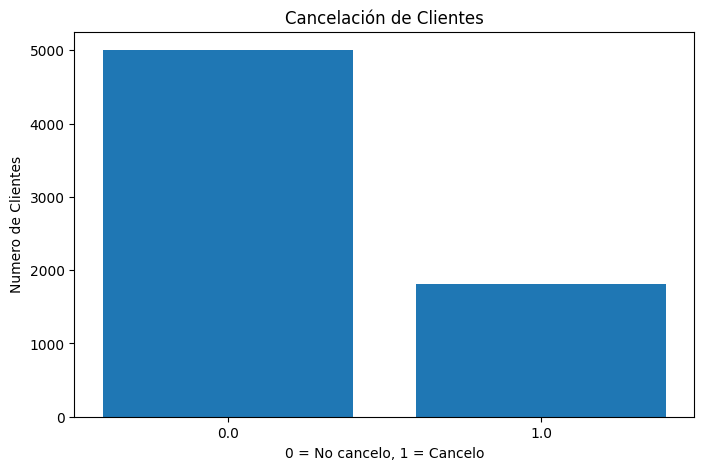

In [78]:
#Recordando que si Churn es 0 NO cancelo, pero si es 1 SI cancelo
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.title("Cancelación de Clientes")
plt.xlabel("0 = No cancelo, 1 = Cancelo")
plt.ylabel("Numero de Clientes")

plt.show()

### 5 - Balanceo de Clases (opcional)

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

* 🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:

In [79]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0.0,0.733685
1.0,0.266315


In [80]:
#Con esto separamos los datoss
X = df.drop('Churn', axis=1)
y = df['Churn']

In [81]:
from sklearn.utils import resample
import pandas as pd

In [82]:
df_mayoria = df[df['Churn'] == 0]
df_minoria = df[df['Churn'] == 1]

df_minoria_oversampled = resample(df_minoria,replace=True,n_samples=len(df_mayoria),random_state=42)
df_balanced = pd.concat([df_mayoria, df_minoria_oversampled])

In [83]:
df_balanced['Churn'].value_counts()

,count
Churn,
0.0,5003
1.0,5003


### 6 - Normalización o Estandarización (si es necesario)

###Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

* 🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
print(X_train_scaled[:1])

[[-0.44657398 -0.98057362  1.53724817 -0.55738635  0.32460716  0.82682645
   0.36402821 -0.40820288  0.36406337 -1.01124563  1.16070932 -0.32460716
   1.39025023 -0.8916268   1.56188039 -0.52509521  1.37954339 -0.52509521
  -0.7263493  -0.52509521  1.55980022 -0.52509521  1.2664196  -0.52509521
  -0.79514535 -0.52509521 -0.51912459 -0.55737595 -0.51542337 -0.723995
   1.84561656]]


In [89]:
print(X_train.shape)
print(X_test.shape)

(5455, 31)
(1364, 31)


In [90]:
print(X_train_scaled.shape[:3])

(5455, 31)


In [91]:
#Con este nos damos cuenta si no se distorsionaron los datos, lo cual es muy muy importante al momento de entrenar modelos.
print(y_train.value_counts())
print(y_test.value_counts())

Churn
0.0    3985
1.0    1470
Name: count, dtype: int64
Churn
0.0    1018
1.0     346
Name: count, dtype: int64


#🎯 Correlación y Selección de Variables

### 1 - Análisis de Correlación

###Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [92]:
corr_churn = df.corr()['Churn'].sort_values(ascending=False)

fig = px.bar(corr_churn,title="Correlación de las Variables con Churn")
fig.show()

In [110]:
import plotly.express as px
#corr = df.corr()
#fig = px.imshow(corr,text_auto=True,aspect="auto",
#                color_continuous_scale="RdBu",title="Matriz de Correlación de Variables")
#fig.show()

### 2 - Análisis Dirigido

###Investiga cómo variables específicas se relacionan con la cancelación, tales como:

* Tiempo de contrato × Cancelación

* Gasto total × Cancelación

###Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [94]:
#Con este se muestra la relacion que existe entre los meses que un cliente lleva utilizando el servicio y la cancelacion
fig = px.histogram(df,x="MesesCliente",color="Churn",
                   nbins=30,title="La distribucion de meses de cliente segun cancelacion")
fig.show()

In [95]:
#Aqui se ve la relacion que hay entre el gasto total del cliente y la cancelacion del servicio
#Es usando scatter plots como fue recomendado en el subtitulo
fig = px.scatter(df,x="MesesCliente",y="CargoTotal",
    color="Churn",title="La relacion entre meses de cliente y gasto Total")

fig.show()

In [96]:
fig = px.histogram(df,x="CargoMensual",color="Churn",
    nbins=30,title="La distribución del cargo mensual segun cancelacion")

fig.show()

#🤖 Modelado Predictivo

### 1 - Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
print(X_train.shape)
print(X_test.shape)

(5455, 31)
(1364, 31)


### 2 - Creación de Modelos

###Crea al menos dos modelos diferentes para predecir la cancelación de clientes. Un modelo puede requerir normalización, como Regresión Logística o KNN. El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

###**💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.**

Justificación:

* Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

* Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

* Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [111]:
#Aqui sera con regresion logistica
#Este usa la data pero ya normalizada
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo_lr.fit(X_train_scaled, y_train)
pred_lr = modelo_lr.predict(X_test_scaled)



In [112]:
#Este es el arbol de decision, y que no necesita estar normalizada
modelo_tree = DecisionTreeClassifier()
modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)

### 3 - Evaluación de los Modelos

###Evalúa cada modelo utilizando las siguientes métricas:

* Exactitud (Acurácia)

* Precisión

* Recall

* F1-score

* Matriz de confusión

###Después, realiza un análisis crítico y compara los modelos:

* ¿Cuál modelo tuvo el mejor desempeño?

* ¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

* Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

* Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [113]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [124]:
#Vemos que el modelo acierta el 50% de las predicciones, tambien que solo el 24% realmente cancelaron.
#Ya luego que el 45% de los clientes que realmente cancelan
print("La regresion logistica")
print("El acierto es de:", accuracy_score(y_test, pred_lr))
print("Su precision es de:", precision_score(y_test, pred_lr))
print("El modelo detecta:", recall_score(y_test, pred_lr))
print("Su rendimiento general es:", f1_score(y_test, pred_lr))

La regresion logistica
El acierto es de: 0.501466275659824
Su precision es de: 0.24148606811145512
El modelo detecta: 0.4508670520231214
Su rendimiento general es: 0.31451612903225806


In [115]:
#Arbolitoo
print("Evaluacion del arbol de decision")
print("El Accuracy:", accuracy_score(y_test, pred_tree))
print("Su precision es:", precision_score(y_test, pred_tree))
print("El modelo detecta:", recall_score(y_test, pred_tree))
print("Su rendimiento general es:", f1_score(y_test, pred_tree))

Evaluacion del arbol de decision
El Accuracy: 0.6041055718475073
Su precision es: 0.25380710659898476
El recall: 0.28901734104046245
F1-score: 0.2702702702702703


In [125]:
confusion_matrix(y_test, pred_lr)
confusion_matrix(y_test, pred_tree)

array([[724, 294],
       [246, 100]])

####En el caso de la regresión logística, se observa un posible problema de underfitting, ya que el modelo no logra capturar adecuadamente las relaciones entre las variables y la cancelación del servicio. Esto provoca que el modelo prediga mayoritariamente la clase dominante.

* Esto indica que el modelo tiene cierta capacidad para identificar cancelaciones, aunque todavía comete varios errores.

####Por otro lado con el arbol de decision, el mismo pudo identificar algunos casos de cancelacion, solo que su desempeño general sigue siendo limitado. Y esto podria ser debido a que es necesario ajustar los parametros del modelo para mejorar su capacidad predictiva.

* El arbol presenta una mayor exactitud general, logrando clasificar correctamente un mayor numero de clientes. Pero la regresión logistica muestra un mejor recall, lo que significa que logra identificar un mayor porcentaje de clientes que realmente cancelan el servicio.

In [117]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

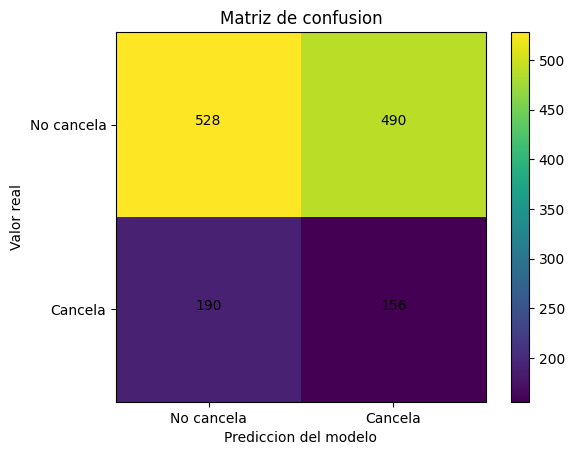

In [130]:
cm = confusion_matrix(y_test, pred_lr)

plt.imshow(cm)
plt.title("Matriz de confusion")
plt.xlabel("Prediccion del modelo")
plt.ylabel("Valor real")
plt.colorbar()

for fila in range(len(cm)):
    for columna in range(len(cm[0])):
        plt.text(columna, fila, cm[fila][columna], ha="center")

plt.xticks([0,1], ["No cancela", "Cancela"])
plt.yticks([0,1], ["No cancela", "Cancela"])
plt.show()

###Con esta podemos comparar los valores reales con las predicciones realizadas por el modelo. Mostrando los casos correctamente clasificados y los errores de prediccion.

* Facilitando mucho el entender cómo el modelo esta identificando a los clientes que cancelan el servicio y a aquellos que continuan.

#📄Informe final

#Conclusión

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.



##Recomendaciones

###Lo que se recomiendo con todo esto es el empezar a fomentar el compromiso a largo plazo. Ya sea que la empresa ofresca descuentos o beneficios exclusivos a quienes decidan cambiarse a planes de uno o dos años. De esta forma, el cliente siente que ahorra dinero y la empresa asegura su permanencia.

###Siendo esto una forma en la que ambas partes ganen, siento otra cosas clave el poder facilitar el proceso de pago. Como el incentivar a los usuarios a registrar pagos automáticos en lugar de usar metodos manuales como el cheque electronico.

* Esto no solo es más comodo para el cliente, sino que reduce las cancelaciones por olvido o por tener que tomar la decisión de pagar cada mes. Y para los clientes que prefieren mantener su flexibilidad mes a mes, se pueden crear programas de fidelización. Al ofrecerles mejoras en su servicio o premios por su antigüedad.

###En cuanto a los modelos predictivos, se aplicaron dos enfoques: regresión logística y árbol de decisión. Ambos modelos permitieron analizar el comportamiento de los datos, aunque mostraron diferencias en su desempeño.

* El arbol de decision obtuvo una mayor exactitud general, mientras que la regresion logística logro identificar una mayor cantidad de clientes que realmente cancelan el servicio.